# CS166 – Social Media Bot Detection
## Data Loading & Preprocessing Notebook
**Team 1:** Aaminah Mohammed, Alex Chang, Jumana Ayoub  
**Course:** CS166 Information Security, Spring 2026  
**Instructor:** Professor Chao-Li Tarng

##Section 1: Data loading

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/aaminahmq/Datafiles/refs/heads/main/CS%20166%20group%20project/twitter_human_bots_dataset.csv"
df = pd.read_csv(url)

# Convert account_type (human/bot) to a number (0/1)
df["Bot Label"] = (df["account_type"] == "bot").astype(int)

print("Dataset loaded successfully!")
print(f"Total rows:    {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Dataset loaded successfully!
Total rows:    37438
Total columns: 24


##Section 2 Basic Data Exploration


In [69]:
# Column names and data types
print("Column names and data types:")
print(df.dtypes)

Column names and data types:
Unnamed: 0                         int64
created_at                        object
default_profile                     bool
default_profile_image               bool
description                       object
favourites_count                   int64
followers_count                    int64
friends_count                      int64
geo_enabled                         bool
id                                 int64
lang                              object
location                          object
profile_background_image_url      object
profile_image_url                 object
screen_name                       object
statuses_count                     int64
verified                            bool
average_tweets_per_day           float64
account_age_days                   int64
account_type                      object
profile_image_path                object
profile_background_image_path     object
split                              int64
Bot Label                   

In [70]:
df.head()

,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,...,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type,profile_image_path,profile_background_image_path,split,Bot Label
0,0,2009-07-04 22:41:51,False,False,NaN,5007,102,168,False,53779179,...,paty_castroo,3974,False,0.978,4063,bot,NaN,NaN,0,1
1,1,2010-01-17 22:54:19,False,False,Television producer. Emmy Award winner. Disney...,1038,60,128,False,105916557,...,CBirckner,259,False,0.067,3866,human,profile_images/4691ae58668d932bb7e7af22141aecf...,profile_images/4691ae58668d932bb7e7af22141aecf...,0,0
2,2,2012-03-01 06:05:32,False,False,NaN,2257,599,449,True,509788597,...,amf_jay,13627,False,4.406,3093,human,NaN,NaN,0,0
3,3,2009-09-01 04:52:30,False,False,NaN,6407,116,334,True,70601327,...,SaraCavolo,4432,False,1.107,4005,human,profile_images/d1da9220e4aa376dff03b6f12765171...,profile_images/d1da9220e4aa376dff03b6f12765171...,0,0
4,4,2010-01-27 17:17:23,False,False,Productor de Televisión - Embajador de @Tienda...,20866,74448,18,True,108999927,...,DavidHenaoModel,15870,True,4.116,3856,human,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,0,0


In [71]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Unnamed: 0                           0
created_at                           0
default_profile                      0
default_profile_image                0
description                       7257
favourites_count                     0
followers_count                      0
friends_count                        0
geo_enabled                          0
id                                   0
lang                              7957
location                             4
profile_background_image_url      4499
profile_image_url                    1
screen_name                          0
statuses_count                       0
verified                             0
average_tweets_per_day               0
account_age_days                     0
account_type                         0
profile_image_path               12938
profile_background_image_path    12938
split                                0
Bot Label                            0
dtype: int64


In [72]:
# How many bots vs real users?
print("Bot Label counts:")
print(df["Bot Label"].value_counts())
print()
print("(1 = Bot, 0 = Real User)")

Bot Label counts:
Bot Label
0    25013
1    12425
Name: count, dtype: int64

(1 = Bot, 0 = Real User)


## Section 3 Handle Missing Values
The Hashtags column has about 8341 missing values  
This just means those tweets had no hashtags, so we fill the blanks with an empty string instead of leaving them as NaN.


In [73]:
# Fill missing text columns with empty string
df["description"] = df["description"].fillna("")
df["location"]    = df["location"].fillna("")
df["lang"]        = df["lang"].fillna("")

print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
Unnamed: 0                           0
created_at                           0
default_profile                      0
default_profile_image                0
description                          0
favourites_count                     0
followers_count                      0
friends_count                        0
geo_enabled                          0
id                                   0
lang                                 0
location                             0
profile_background_image_url      4499
profile_image_url                    1
screen_name                          0
statuses_count                       0
verified                             0
average_tweets_per_day               0
account_age_days                     0
account_type                         0
profile_image_path               12938
profile_background_image_path    12938
split                                0
Bot Label                            0
dtype: int64


##Section 4 Feature Engineering


In [74]:
# Convert boolean columns to 0/1
for col in ["default_profile", "default_profile_image", "geo_enabled", "verified"]:
    df[col] = df[col].astype(int)

# Description length (longer descriptions = more likely human)
df["description_length"] = df["description"].str.len()

# Followers to friends ratio (bots often follow many but have few followers)
df["followers_friends_ratio"] = df["followers_count"] / (df["friends_count"] + 1)

print("Features ready!")
df[["default_profile", "verified", "description_length", "followers_friends_ratio"]].head()

Features ready!


,default_profile,verified,description_length,followers_friends_ratio
0,0,0,0,0.603550
1,0,0,86,0.465116
2,0,0,0,1.331111
3,0,0,0,0.346269
4,0,1,140,3918.315789


##Section 5 Features for the model

In [75]:
features = [
    "followers_count",
    "friends_count",
    "favourites_count",
    "statuses_count",
    "verified",
    "default_profile",
    "default_profile_image",
    "geo_enabled",
    "average_tweets_per_day",
    "account_age_days",
    "description_length",
    "followers_friends_ratio"
]

target = "Bot Label"

X = df[features]
y = df[target]

print("Features selected for the model:")
for f in features:
    print(f"  - {f}")
print(f"\nTarget: {target}  (1 = Bot, 0 = Real User)")

Features selected for the model:
  - followers_count
  - friends_count
  - favourites_count
  - statuses_count
  - verified
  - default_profile
  - default_profile_image
  - geo_enabled
  - average_tweets_per_day
  - account_age_days
  - description_length
  - followers_friends_ratio

Target: Bot Label  (1 = Bot, 0 = Real User)


In [76]:
# Summary statistics for our selected features
X.describe().round(2)

,followers_count,friends_count,favourites_count,statuses_count,verified,default_profile,default_profile_image,geo_enabled,average_tweets_per_day,account_age_days,description_length,followers_friends_ratio
count,3.743800e+04,37438.00,37438.00,37438.00,37438.0,37438.00,37438.00,37438.00,37438.00,37438.00,37438.00,37438.00
mean,3.703098e+05,4445.93,12302.06,21073.39,0.2,0.42,0.01,0.46,6.89,3022.13,67.02,14410.06
std,2.470829e+06,49545.20,33923.65,67329.77,0.4,0.49,0.12,0.50,24.58,1013.70,55.22,544999.19
min,0.000000e+00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,483.00,0.00,0.00
25%,3.500000e+01,37.00,362.00,1336.25,0.0,0.00,0.00,0.00,0.50,2316.25,14.00,0.46
50%,3.650000e+02,296.00,2066.00,4209.00,0.0,0.00,0.00,0.00,1.49,3219.00,58.00,1.41
75%,8.440250e+03,893.00,8879.00,17153.75,0.0,1.00,0.00,1.00,5.53,3888.00,118.00,28.48
max,1.216415e+08,4343060.00,885123.00,2771910.00,1.0,1.00,1.00,1.00,1269.06,5158.00,191.00,86990481.00


## Section 6: Train / Test Split
We split the data so that:
- 80% is used to train the model
- 20% is used to test how well the model does on data it has never seen before

random_state=42 makes sure we get the same split every time we run the notebook

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")

Training set:  29950 rows
Test set:      7488 rows


##Section 7 feature scaling

In [78]:
 #scaling the features

scaler = StandardScaler()

# Fit on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print()
print("Data is ready for model training!")

Scaling complete!
X_train_scaled shape: (29950, 12)
X_test_scaled shape:  (7488, 12)

Data is ready for model training!


##Section 8 Data visualizations

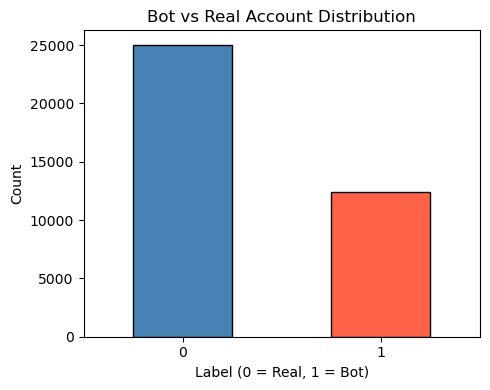

In [79]:
#bot vs real account distributions
plt.figure(figsize=(5, 4))
df["Bot Label"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"],
    edgecolor="black"
)
plt.title("Bot vs Real Account Distribution")
plt.xlabel("Label (0 = Real, 1 = Bot)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

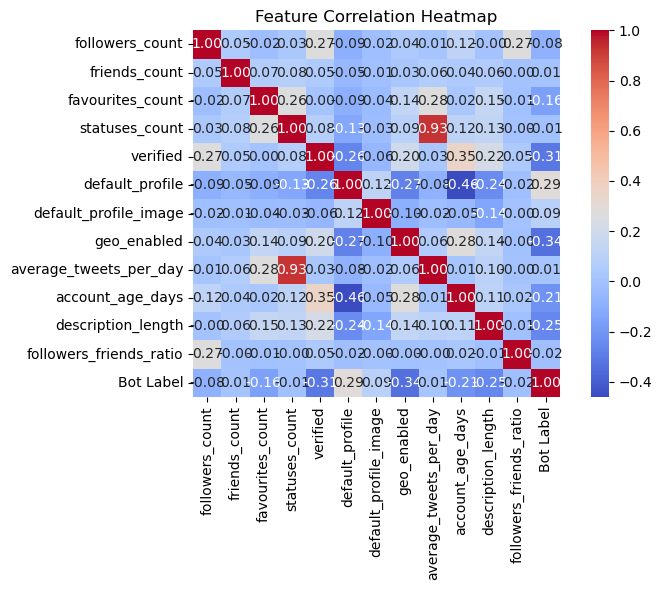

In [80]:
# feature correlation

plt.figure(figsize=(8, 6))
corr = df[features + [target]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Section 7: The Models

### Random Forest Classifier

--- Random Forest Performance ---
Accuracy Score: 0.8822
AUC-ROC:        0.9348

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      5033
           1       0.86      0.77      0.81      2455

    accuracy                           0.88      7488
   macro avg       0.87      0.85      0.86      7488
weighted avg       0.88      0.88      0.88      7488



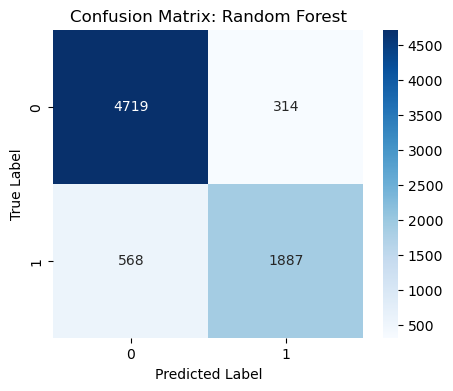

In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

rf_model = RandomForestClassifier(n_estimators=500, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("--- Random Forest Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:        {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

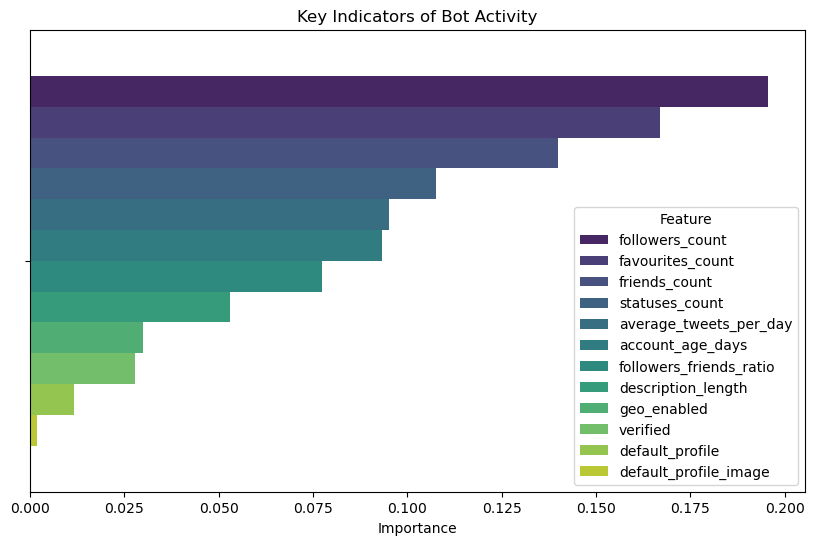

In [92]:
# Extract feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', hue='Feature', data=feature_importance_df, palette='viridis')
plt.title('Key Indicators of Bot Activity')
plt.show()

### Linear Regression

--- Logistic Regression Performance ---
Accuracy Score: 0.7615
AUC-ROC:        0.8222

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      5033
           1       0.65      0.60      0.62      2455

    accuracy                           0.76      7488
   macro avg       0.73      0.72      0.72      7488
weighted avg       0.76      0.76      0.76      7488



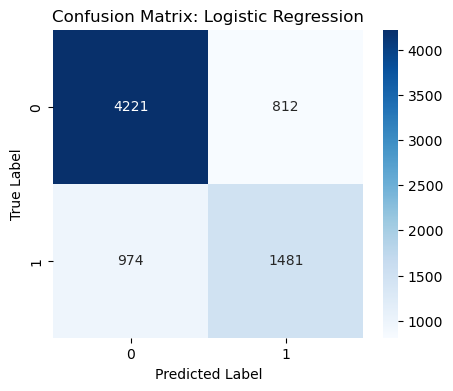

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("--- Logistic Regression Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:        {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

###Decision Tree Classifier

--- Decision Tree Performance ---
Accuracy:  0.8562
AUC-ROC:   0.8808

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      5033
           1       0.81      0.74      0.77      2455

    accuracy                           0.86      7488
   macro avg       0.84      0.83      0.83      7488
weighted avg       0.85      0.86      0.85      7488



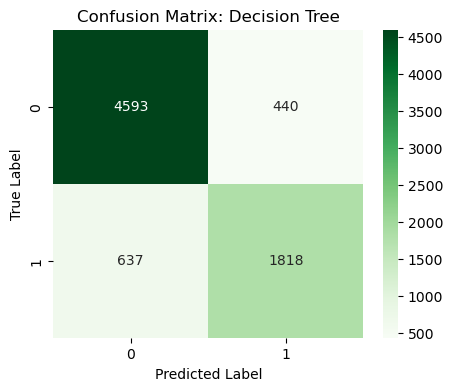

In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Train
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("--- Decision Tree Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### XGBoost Classifier

In [ ]:
!pip install xgboost #only run this line if xgboost is not already installed in your environment

--- XGBoost Performance ---
Accuracy:  0.8790
AUC-ROC:   0.9336

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      5033
           1       0.84      0.77      0.81      2455

    accuracy                           0.88      7488
   macro avg       0.87      0.85      0.86      7488
weighted avg       0.88      0.88      0.88      7488



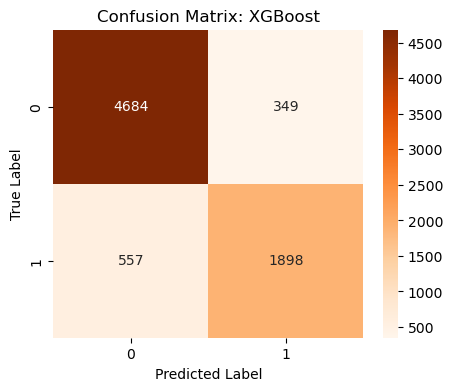

In [95]:
from xgboost import XGBClassifier

# Train
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss", n_estimators=100)
xgb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("--- XGBoost Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix: XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Knearest Neighbor

  K=3  ->  Accuracy: 0.7922
  K=5  ->  Accuracy: 0.8002
  K=7  ->  Accuracy: 0.7979
  K=11  ->  Accuracy: 0.7981

Best K: 5  (Accuracy: 0.8002)

--- KNN Performance (K=5) ---
Accuracy:  0.8002
AUC-ROC:   0.8487

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      5033
           1       0.69      0.70      0.70      2455

    accuracy                           0.80      7488
   macro avg       0.77      0.78      0.77      7488
weighted avg       0.80      0.80      0.80      7488



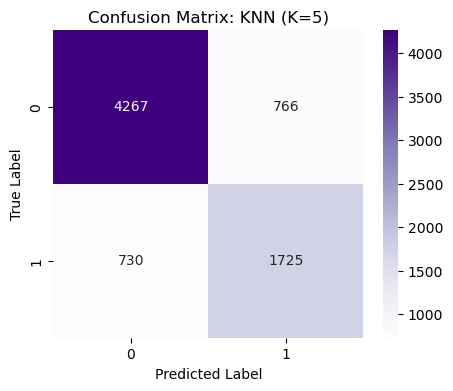

In [86]:
from sklearn.neighbors import KNeighborsClassifier

# Try different values of K
k_values = [3, 5, 7, 11]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    knn_results[k] = acc
    print(f"  K={k}  ->  Accuracy: {acc:.4f}")

best_k = max(knn_results, key=knn_results.get)
print(f"\nBest K: {best_k}  (Accuracy: {knn_results[best_k]:.4f})")

# Train final KNN with best K
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print()
print(f"--- KNN Performance (K={best_k}) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_knn):.4f}")
print()
print(classification_report(y_test, y_pred_knn))

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Purples")
plt.title(f"Confusion Matrix: KNN (K={best_k})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Models Comparison

In [96]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_auc_score

models_info = {
    "Logistic Regression": (y_pred_lr,  y_prob_lr),
    "Random Forest":       (y_pred_rf,  y_prob_rf),
    "Decision Tree":       (y_pred_dt,  y_prob_dt),
    "XGBoost":             (y_pred_xgb, y_prob_xgb),
    f"KNN (K={best_k})":   (y_pred_knn, y_prob_knn),
}

rows = []
for name, (preds, probs) in models_info.items():
    rows.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall":    round(recall_score(y_test, preds), 4),
        "F1-Score":  round(f1_score(y_test, preds), 4),
        "AUC-ROC":   round(roc_auc_score(y_test, probs), 4),
    })

results_df = pd.DataFrame(rows).set_index("Model")
print("Model Comparison Table:")
print(results_df.to_string())

Model Comparison Table:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.7615     0.6459  0.6033    0.6238   0.8222
Random Forest          0.8822     0.8573  0.7686    0.8106   0.9348
Decision Tree          0.8562     0.8051  0.7405    0.7715   0.8808
XGBoost                0.8790     0.8447  0.7731    0.8073   0.9336
KNN (K=5)              0.8002     0.6925  0.7026    0.6975   0.8487


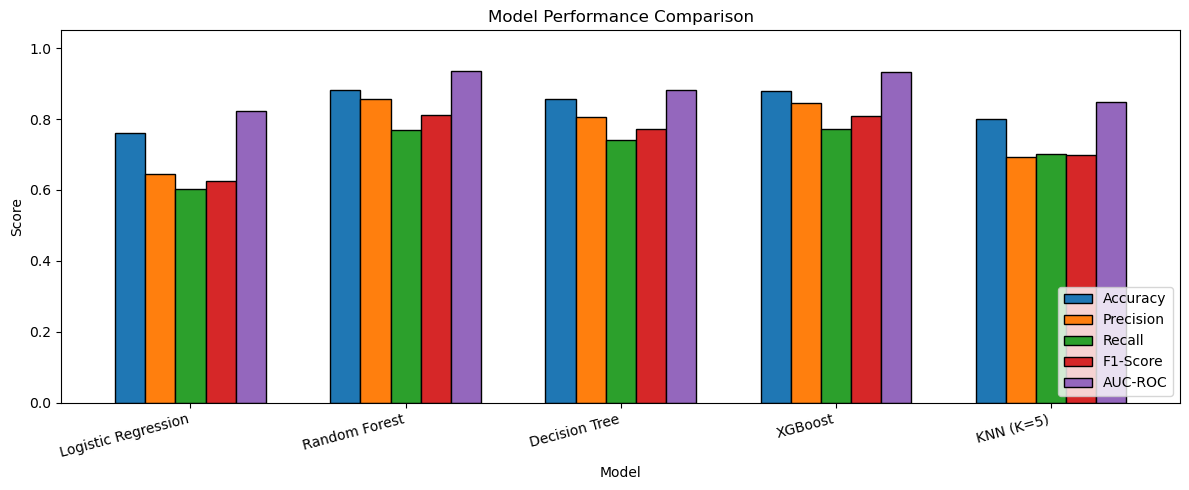

In [97]:
# Bar chart comparing all models
ax = results_df[["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]].plot(
    kind="bar", figsize=(12, 5), edgecolor="black", width=0.7
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


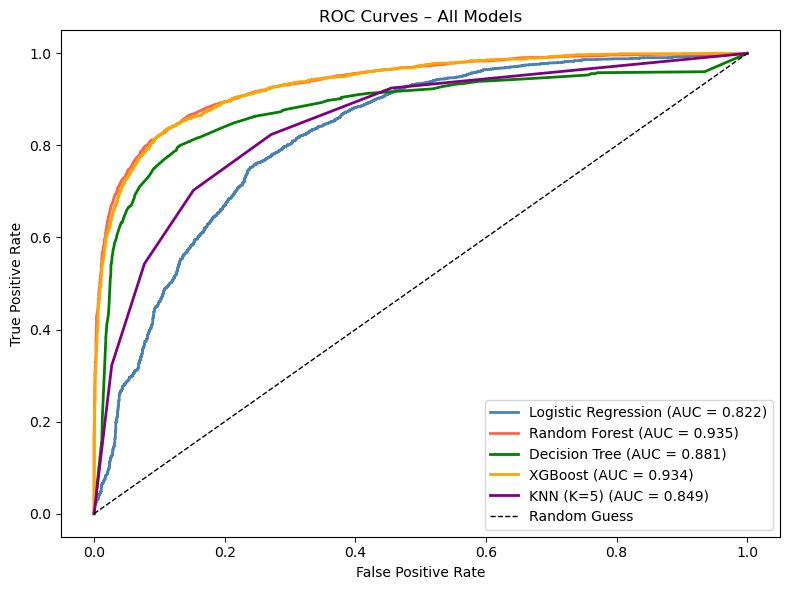

In [98]:
# ROC curves for all models
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

colors = ["steelblue", "tomato", "green", "orange", "purple"]
for (name, (preds, probs)), color in zip(models_info.items(), colors):
    if probs is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
